# Baseline models

In [1]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

In [2]:
df = pd.read_csv('../data/clean/full_data.csv')

In [3]:
df.head()

,casos,week-canton,relative_risk,classi_rr,urb,tmax_min,tmax_max,tmax_mean,tmax_median,tmin_min,tmin_max,tmin_mean,tmin_median,precip_total,precip_min,precip_max,precip_mean,precip_median
0,2,2020-1-507,3.011235,Alto,0,31.206179,34.216175,32.980368,33.278346,31.206179,34.216175,32.980368,33.278346,16.483572,0.0,8.394386,0.686816,0.0
1,0,2020-1-112,0.000000,Bajo,2,27.300568,31.489710,28.930743,28.016085,27.300568,31.489710,28.930743,28.016085,77.464812,0.0,37.667015,6.455401,0.0
2,29,2020-1-201,2.763229,Alto,1,21.756056,29.411386,26.367157,27.010843,21.756056,29.411386,26.367157,27.010843,56.828430,0.0,32.674007,3.551777,0.0
3,4,2020-1-110,1.288112,Alto,1,23.514788,24.153862,23.886117,23.937909,23.514788,24.153862,23.886117,23.937909,11.819548,0.0,11.819548,2.954887,0.0
4,0,2020-1-306,0.000000,Bajo,2,23.673475,24.585056,24.102187,24.075108,23.673475,24.585056,24.102187,24.075108,27.596506,0.0,27.596506,6.899127,0.0


In [4]:
# CHANGE THIS WHEN THE DATA IS OK, THIS IS BASICALLY A SIN TO GET THE MODEL TO WORK
df.drop(columns=['casos'], inplace=True)
df.dropna(inplace=True)

In [5]:
df.shape

(18600, 17)

In [6]:
df = pd.get_dummies(df, columns = ["urb"])

In [7]:
df.head()

,week-canton,relative_risk,classi_rr,tmax_min,tmax_max,tmax_mean,tmax_median,tmin_min,tmin_max,tmin_mean,tmin_median,precip_total,precip_min,precip_max,precip_mean,precip_median,urb_0,urb_1,urb_2
0,2020-1-507,3.011235,Alto,31.206179,34.216175,32.980368,33.278346,31.206179,34.216175,32.980368,33.278346,16.483572,0.0,8.394386,0.686816,0.0,True,False,False
1,2020-1-112,0.000000,Bajo,27.300568,31.489710,28.930743,28.016085,27.300568,31.489710,28.930743,28.016085,77.464812,0.0,37.667015,6.455401,0.0,False,False,True
2,2020-1-201,2.763229,Alto,21.756056,29.411386,26.367157,27.010843,21.756056,29.411386,26.367157,27.010843,56.828430,0.0,32.674007,3.551777,0.0,False,True,False
3,2020-1-110,1.288112,Alto,23.514788,24.153862,23.886117,23.937909,23.514788,24.153862,23.886117,23.937909,11.819548,0.0,11.819548,2.954887,0.0,False,True,False
4,2020-1-306,0.000000,Bajo,23.673475,24.585056,24.102187,24.075108,23.673475,24.585056,24.102187,24.075108,27.596506,0.0,27.596506,6.899127,0.0,False,False,True


In [8]:
train = df[df['week-canton'] < '2024-1-101']
val = df[(df['week-canton'] >= '2024-1-101') & (df['week-canton'] < '2025-1-101')]
test = df[df['week-canton'] >= '2025-1-101']

X_train = train.drop(columns = ["relative_risk", "classi_rr", "week-canton"])
y_train = train["classi_rr"]

X_val = val.drop(columns = ["relative_risk", "classi_rr", "week-canton"])
y_val= val["classi_rr"]

X_test= test.drop(columns = ["relative_risk", "classi_rr", "week-canton"])
y_test = test["classi_rr"]

In [9]:
scaler = StandardScaler()  

X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_val_scaled = pd.DataFrame(scaler.transform(X_val), columns=X_val.columns)  
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

In [10]:
X_test_for_reg = pd.concat([X_val, X_test], axis=0)
y_test_for_reg = pd.concat([y_val, y_test], axis=0)

X_test_for_reg_scaled = pd.DataFrame(scaler.transform(X_test_for_reg), columns=X_test_for_reg.columns)

In [11]:
train.shape, val.shape, test.shape

((12958, 19), (3224, 19), (2418, 19))

## Logistic regression

In [12]:
reg = LogisticRegression()

reg.fit(X_train_scaled, y_train)

y_pred_reg = reg.predict(X_test_for_reg_scaled)

In [19]:
print(classification_report(y_test_for_reg, y_pred_reg))

              precision    recall  f1-score   support

        Alto       0.45      0.24      0.32      2122
        Bajo       0.53      0.87      0.66      2736
       Medio       0.07      0.00      0.01       784

    accuracy                           0.51      5642
   macro avg       0.35      0.37      0.33      5642
weighted avg       0.44      0.51      0.44      5642



In [16]:
cnf_matrix_reg = confusion_matrix(y_test_for_reg, y_pred_reg)
cnf_matrix_reg

array([[ 514, 1570,   38],
       [ 364, 2371,    1],
       [ 254,  527,    3]])

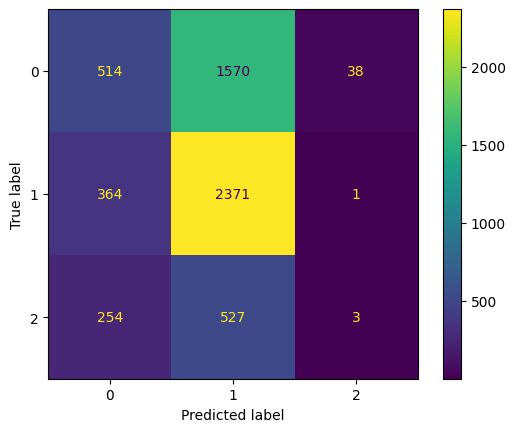

In [17]:
ConfusionMatrixDisplay(confusion_matrix=cnf_matrix_reg).plot()

### Random forest

In [20]:
rf = RandomForestClassifier()

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test_for_reg_scaled)

In [21]:
print(classification_report(y_test_for_reg, y_pred_rf))

              precision    recall  f1-score   support

        Alto       0.00      0.00      0.00      2122
        Bajo       0.48      1.00      0.65      2736
       Medio       0.00      0.00      0.00       784

    accuracy                           0.48      5642
   macro avg       0.16      0.33      0.22      5642
weighted avg       0.24      0.48      0.32      5642



c:\Users\nan\OneDrive - Universidad de Costa Rica\cuenta personal\ucr pers\practica profesional\practica dengue\dengue-model\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\nan\OneDrive - Universidad de Costa Rica\cuenta personal\ucr pers\practica profesional\practica dengue\dengue-model\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\nan\OneDrive - Universidad de Costa Rica\cuenta personal\ucr pers\practica profesional\practica dengue\dengue-model\.venv\Lib\site-

In [23]:
cnf_matrix_rf = confusion_matrix(y_test_for_reg, y_pred_rf)
cnf_matrix_rf

array([[   0, 2122,    0],
       [   0, 2736,    0],
       [   0,  784,    0]])

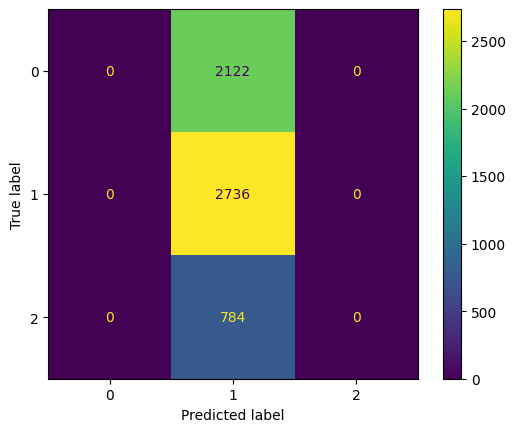

In [24]:
ConfusionMatrixDisplay(confusion_matrix=cnf_matrix_rf).plot()

<Axes: >

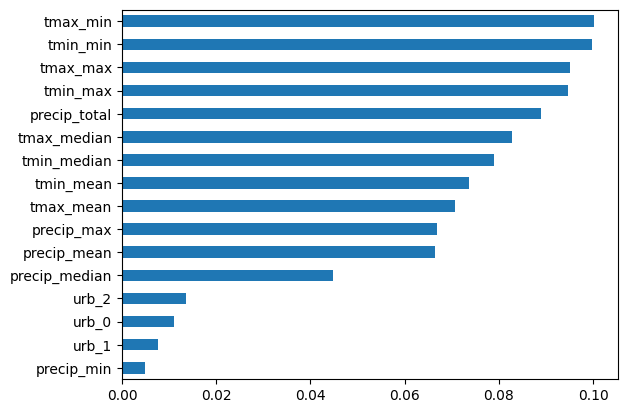

In [28]:
importances = pd.Series(rf.feature_importances_, index=X_train.columns)
importances.sort_values(ascending=True).plot.barh()